## Backpropagation Implementation

Iteration 0: loss=1.7093, a2=[0.97499937 0.92016053 0.95243143 0.97805664 0.89325337 0.95110802
 0.98791872 0.87754222 0.85709859 0.96663331 0.98986323 0.98383643
 0.91577126 0.83647644 0.93584273 0.80936112 0.97902335 0.99023692
 0.98780052 0.83456443 0.97427316 0.95990489 0.90956117 0.86048306
 0.98826253 0.9756473  0.86814303 0.96103452 0.92189638 0.92873606
 0.93740183 0.95451339 0.93581966 0.89927194 0.9805233  0.90297337
 0.87302974 0.63997297 0.96711952 0.98697272 0.92487977 0.99166884
 0.93535295 0.97487204 0.88972293 0.91396608 0.93178011 0.97766425
 0.95759949 0.96243146 0.88821368 0.96657631 0.92634729 0.98971271
 0.96668133 0.79712841 0.84883815 0.92977588 0.98000071 0.96964809
 0.98856918 0.99377672 0.88753388 0.92872127 0.97232287 0.82449462
 0.83747509 0.7838968  0.92637835 0.99020493 0.90549044 0.8053797
 0.93391377 0.95495714 0.96484557 0.95245055 0.89622478 0.98018344
 0.98646848 0.80633134 0.82149996 0.99105808 0.97404008 0.9116736
 0.96825154 0.94706539 0.93512089 0

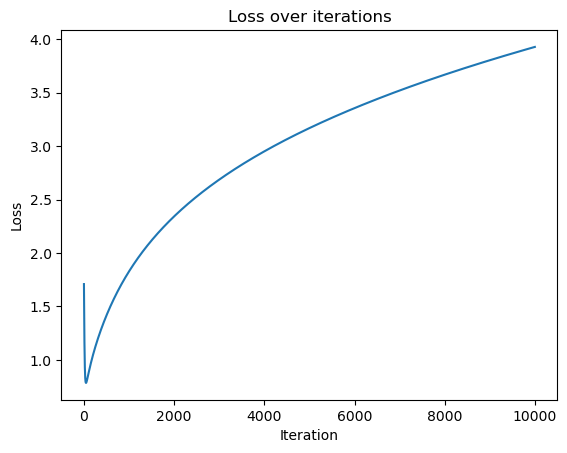

In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

# data
np.random.seed(42)
X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# model
class NeuralnetworkFromScratch:
    def __init__(self, learning_rate=0.1, n_iterations=10000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.W1 = None
        self.b1 = None
        self.W2 = None
        self.b2 = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def initialize_weights(self, n_input, n_hidden, n_output):
        self.W1 = np.random.randn(n_input, n_hidden) * 1.0
        self.b1 = np.zeros(n_hidden)
        self.W2 = np.random.randn(n_hidden, n_output) * 1.0
        self.b2 = np.zeros(n_output)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.sigmoid(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self.sigmoid(z2)
        return a1, a2

    # backward pass
    def backward(self, X, y, a1, a2):
        n = len(y)
        delta2 = a2 - y.reshape(-1, 1)
        dW2 = (1/n) * a1.T @ delta2
        db2 = (1/n) * np.sum(delta2, axis=0)
        delta1 = delta2 @ self.W2.T * a1 * (1 - a1)
        dW1 = (1/n) * X.T @ delta1
        db1 = (1/n) * np.sum(delta1, axis=0)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y):
        self.initialize_weights(n_input=2, n_hidden=4, n_output=1)
        for i in range(self.n_iter):
            a1, a2 = self.forward(X)
            self.backward(X, y, a1, a2)
            loss = -np.mean(y * np.log(a2 + 1e-8) +
                       (1-y) * np.log(1-a2 + 1e-8))
            self.loss_history.append(loss)
            if i % 10000 == 0:
                print(f"Iteration {i}: loss={loss:.4f}, a2={a2.flatten()}")

# train and evaluate
model = NeuralnetworkFromScratch(learning_rate=0.1, n_iterations=10000)
model.fit(X, y)

a1, a2 = model.forward(X)
predictions = (a2 >= 0.5).astype(int).flatten()
accuracy = np.mean(predictions == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

# plotting loss curve
plt.plot(model.loss_history)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [2]:
# XOR dataset
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

model_xor = NeuralnetworkFromScratch(learning_rate=1.0, n_iterations=10000)
model_xor.fit(X_xor, y_xor)

a1, a2 = model_xor.forward(X_xor)
predictions = (a2 >= 0.5).astype(int).flatten()
print(f"Predictions: {predictions}")
print(f"True labels: {y_xor}")
accuracy = np.mean(predictions == y_xor)
print(f"Accuracy: {accuracy * 100:.2f}%")

Iteration 0: loss=0.7313, a2=[0.44040189 0.33841578 0.40965641 0.31505312]
Predictions: [0 1 1 0]
True labels: [0 1 1 0]
Accuracy: 100.00%


In [3]:
# higher lr and more iterations
for attempt in range(10):
    np.random.seed(attempt)
    model_xor = NeuralnetworkFromScratch(learning_rate=0.5, n_iterations=50000)
    model_xor.fit(X_xor, y_xor)
    a1, a2 = model_xor.forward(X_xor)
    predictions = (a2 >= 0.5).astype(int).flatten()
    accuracy = np.mean(predictions == y_xor)
    print(f"Attempt {attempt+1}: predictions={predictions}, accuracy={accuracy*100:.1f}%")

Iteration 0: loss=0.8727, a2=[0.72168765 0.6897504  0.82876192 0.81259969]
Iteration 10000: loss=3.2104, a2=[0.00180794 0.99839776 0.99870533 0.00188189]
Iteration 20000: loss=3.5855, a2=[8.65007431e-04 9.99237201e-01 9.99400860e-01 8.85361180e-04]
Iteration 30000: loss=3.7996, a2=[5.67081101e-04 9.99499508e-01 9.99614657e-01 5.76285555e-04]
Iteration 40000: loss=3.9501, a2=[4.21363075e-04 9.99627367e-01 9.99717583e-01 4.26408547e-04]
Attempt 1: predictions=[0 1 1 0], accuracy=100.0%
Iteration 0: loss=0.7533, a2=[0.43433595 0.68796372 0.54888958 0.75509485]
Iteration 10000: loss=3.3578, a2=[4.28537676e-04 9.98649551e-01 9.98569094e-01 2.61915016e-03]
Iteration 20000: loss=3.7751, a2=[2.02083543e-04 9.99403305e-01 9.99409876e-01 1.07874166e-03]
Iteration 30000: loss=4.0114, a2=[1.32943067e-04 9.99627851e-01 9.99639858e-01 6.49739863e-04]
Iteration 40000: loss=4.1758, a2=[9.95104711e-05 9.99732794e-01 9.99743850e-01 4.56175277e-04]
Attempt 2: predictions=[0 1 1 0], accuracy=100.0%
Iterat